In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [6]:
df = pd.read_csv("shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


In [8]:
print(df.isna())

      Customer ID    Age  Gender  Item Purchased  Category  \
0           False  False   False           False     False   
1           False  False   False           False     False   
2           False  False   False           False     False   
3           False  False   False           False     False   
4           False  False   False           False     False   
...           ...    ...     ...             ...       ...   
3895        False  False   False           False     False   
3896        False  False   False           False     False   
3897        False  False   False           False     False   
3898        False  False   False           False     False   
3899        False  False   False           False     False   

      Purchase Amount (USD)  Location   Size  Color  Season  Review Rating  \
0                     False     False  False  False   False          False   
1                     False     False  False  False   False          False   
2                    

In [11]:
print(df.isna().sum())

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [13]:
df.duplicated()[df.duplicated()==True]

,0


In [15]:
print("Shape (rows, columns): ", df.shape,"\n")
print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3900, 16) 

number of rows:  3900
number of columns:  16


In [19]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [23]:
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].astype(str).replace(r'[\$,]', '', regex=True)
df['Purchase Amount (USD)'] = pd.to_numeric(df['Purchase Amount (USD)'])

categorical_cols = ['Gender', 'Category', 'Location', 'Size', 'Color', 'Season',
                    'Subscription Status', 'Discount Applied', 'Payment Method', 'Frequency of Purchases']
df[categorical_cols] = df[categorical_cols].astype('category')

print(df.dtypes)

Customer ID                  int64
Age                          int64
Gender                    category
Item Purchased              object
Category                  category
Purchase Amount (USD)        int64
Location                  category
Size                      category
Color                     category
Season                    category
Review Rating              float64
Subscription Status       category
Discount Applied          category
Previous Purchases           int64
Payment Method            category
Frequency of Purchases    category
dtype: object


In [25]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,38.000000,NaN,NaN


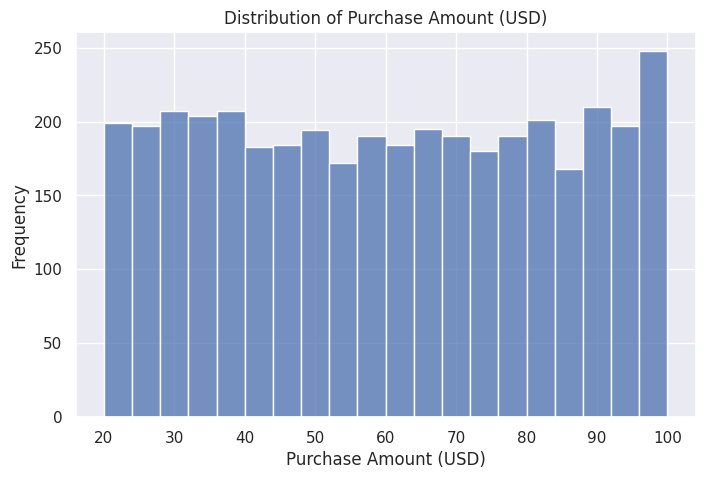

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Purchase Amount (USD)'], bins=20)
plt.title("Distribution of Purchase Amount (USD)")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")
plt.show()

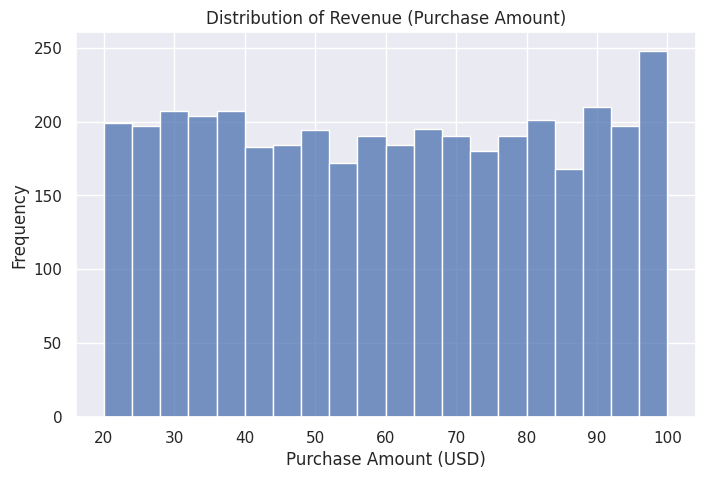

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Purchase Amount (USD)'], bins=20)
plt.title("Distribution of Revenue (Purchase Amount)")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")
plt.show()

/tmp/ipython-input-4263305705.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  location_revenue = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)


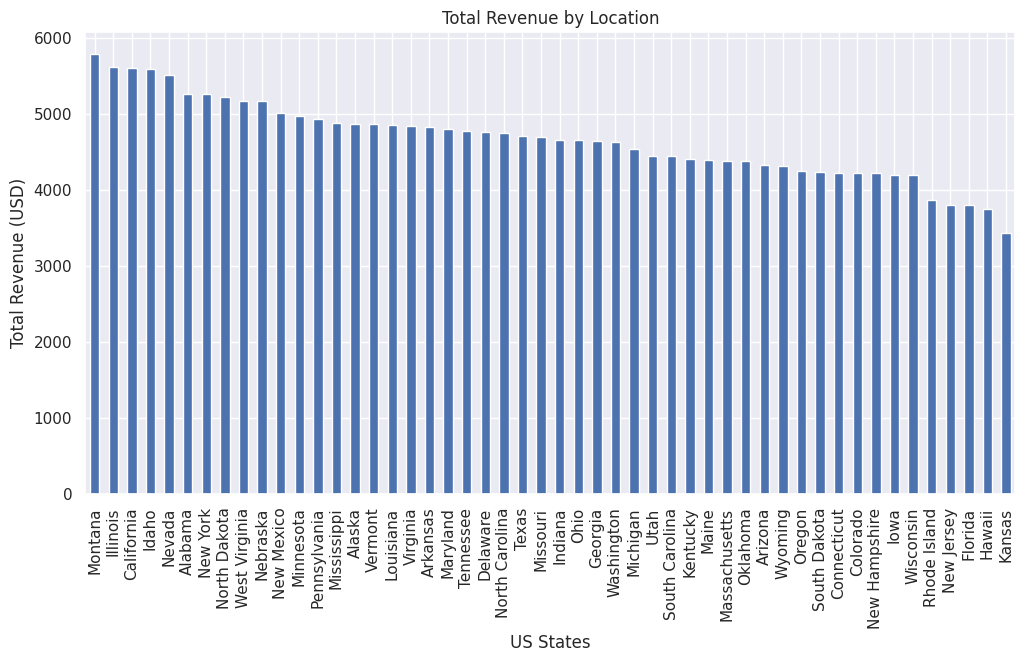

Location
Montana           5784
Illinois          5617
California        5605
Idaho             5587
Nevada            5514
Alabama           5261
New York          5257
North Dakota      5220
West Virginia     5174
Nebraska          5172
New Mexico        5014
Minnesota         4977
Pennsylvania      4926
Mississippi       4883
Alaska            4867
Vermont           4860
Louisiana         4848
Virginia          4842
Arkansas          4828
Maryland          4795
Tennessee         4772
Delaware          4758
North Carolina    4742
Texas             4712
Missouri          4691
Indiana           4655
Ohio              4649
Georgia           4645
Washington        4623
Michigan          4533
Utah              4443
South Carolina    4439
Kentucky          4402
Maine             4388
Massachusetts     4384
Oklahoma          4376
Arizona           4326
Wyoming           4309
Oregon            4243
South Dakota      4236
Connecticut       4226
Colorado          4222
New Hampshire     4219
Io

In [41]:
location_revenue = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
location_revenue.plot(kind='bar')
plt.title("Total Revenue by Location")
plt.xlabel("US States")
plt.ylabel("Total Revenue (USD)")
plt.show()
print(location_revenue)

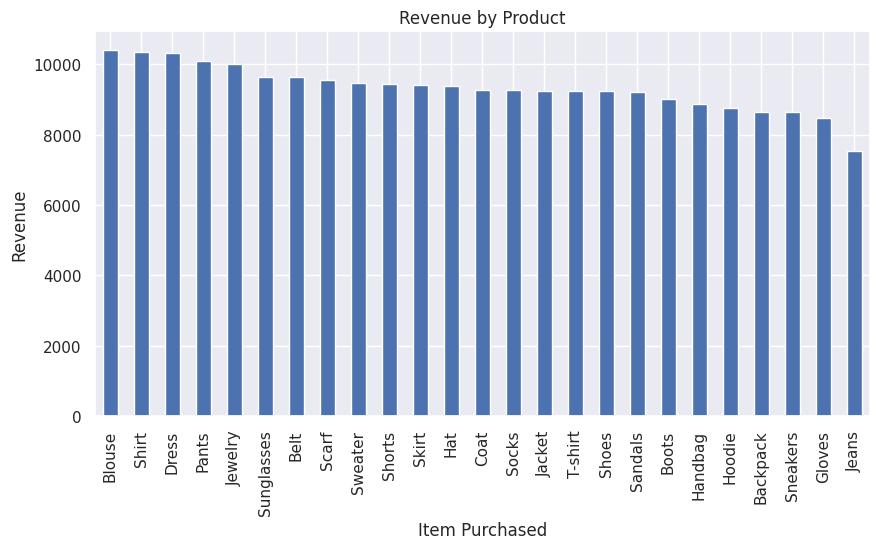

,Purchase Amount (USD)
Item Purchased,
Blouse,10410
Shirt,10332
Dress,10320
Pants,10090
Jewelry,10010
Sunglasses,9649
Belt,9635
Scarf,9561
Sweater,9462


In [43]:
product_revenue = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()
product_revenue

In [45]:
category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

category_revenue.head(10)

/tmp/ipython-input-366734688.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)


,Purchase Amount (USD)
Category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


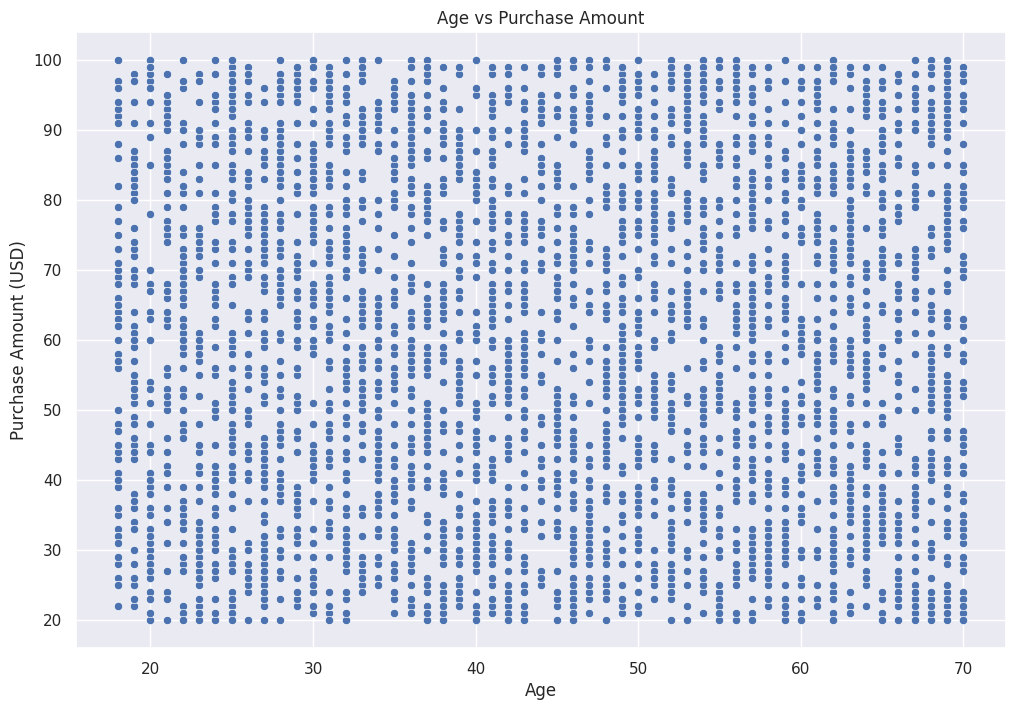

In [49]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='Age', y='Purchase Amount (USD)', data=df)
plt.title("Age vs Purchase Amount")
plt.show()

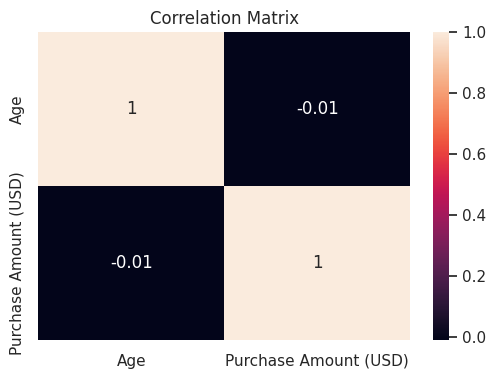

In [51]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'Purchase Amount (USD)']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

/tmp/ipython-input-2815919249.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_revenue = df.groupby('Season')['Purchase Amount (USD)'].sum()


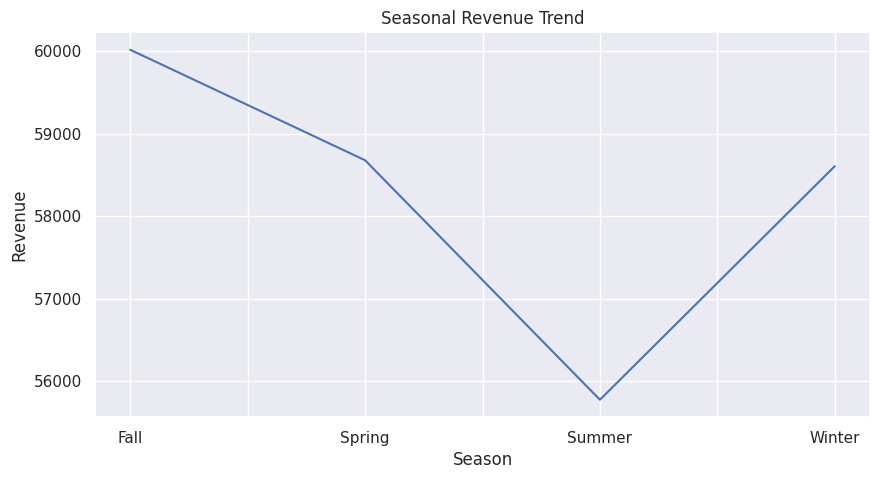

,Purchase Amount (USD)
Season,
Fall,60018
Spring,58679
Summer,55777
Winter,58607


In [54]:
seasonal_revenue = df.groupby('Season')['Purchase Amount (USD)'].sum()
plt.figure(figsize=(10,5))
seasonal_revenue.plot()
plt.title("Seasonal Revenue Trend")
plt.ylabel("Revenue")
plt.show()
seasonal_revenue